In [4]:
import os
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import yaml
from corner import corner
from tqdm.auto import tqdm

from mejiro.utils import util

# read configuration file
config_file = os.path.join(os.path.expanduser('~'), 'mejiro', 'mejiro', 'data', 'mejiro_config', 'jwst.yaml')  # roman_data_challenge_rung_1
with open(config_file, 'r') as f:
    config = yaml.load(f, Loader=yaml.SafeLoader)

if config['dev']:
    config['pipeline_label'] += '_dev'

data_dir = os.path.join(config['data_dir'], config['pipeline_label'], '01b')
print(f'Data directory: {data_dir}')

Data directory: /data/bwedig/mejiro/jwst_dev/01b


In [2]:
# load all detectable gglens pickle files
pkl_paths = sorted(glob(os.path.join(data_dir, 'detectable_gglenses_*.pkl')))
print(f'Found {len(pkl_paths)} pickle file(s)')

all_lenses = []
file_counts = []
for path in pkl_paths:
    lenses = util.unpickle(path)
    file_counts.append((os.path.basename(path), len(lenses)))
    all_lenses.extend(lenses)

print(f'Total detectable lenses: {len(all_lenses)}')
print(f'\nLenses per run:')
for name, count in file_counts:
    print(f'  {name}: {count}')

Found 32 pickle file(s)
Total detectable lenses: 7631

Lenses per run:
  detectable_gglenses_0000.pkl: 233
  detectable_gglenses_0001.pkl: 215
  detectable_gglenses_0002.pkl: 270
  detectable_gglenses_0003.pkl: 204
  detectable_gglenses_0004.pkl: 260
  detectable_gglenses_0005.pkl: 227
  detectable_gglenses_0006.pkl: 212
  detectable_gglenses_0007.pkl: 247
  detectable_gglenses_0008.pkl: 240
  detectable_gglenses_0009.pkl: 212
  detectable_gglenses_0010.pkl: 246
  detectable_gglenses_0011.pkl: 260
  detectable_gglenses_0012.pkl: 248
  detectable_gglenses_0013.pkl: 244
  detectable_gglenses_0014.pkl: 228
  detectable_gglenses_0015.pkl: 229
  detectable_gglenses_0016.pkl: 253
  detectable_gglenses_0017.pkl: 254
  detectable_gglenses_0018.pkl: 231
  detectable_gglenses_0019.pkl: 242
  detectable_gglenses_0020.pkl: 245
  detectable_gglenses_0021.pkl: 262
  detectable_gglenses_0022.pkl: 239
  detectable_gglenses_0023.pkl: 241
  detectable_gglenses_0024.pkl: 252
  detectable_gglenses_0025.pk

In [5]:
use_cache = True
cache_path = os.path.join(data_dir, 'lens_properties_cache.npz')

if use_cache and os.path.exists(cache_path):
    data = np.load(cache_path)
    z_deflector = data['z_deflector']
    z_source = data['z_source']
    einstein_radii = data['einstein_radii']
    stellar_masses = data['stellar_masses']
    velocity_dispersions = data['velocity_dispersions']
    magnifications = data['magnifications']
    image_numbers = data['image_numbers']
    print(f'Loaded cached properties for {len(z_deflector)} lenses from {cache_path}')
else:
    z_deflector = []
    z_source = []
    einstein_radii = []
    stellar_masses = []
    velocity_dispersions = []
    magnifications = []
    image_numbers = []

    for lens in tqdm(all_lenses):
        z_deflector.append(lens.deflector_redshift)
        z_source.append(lens.source_redshift_list[0])
        einstein_radii.append(lens.einstein_radius[0])
        stellar_masses.append(lens.deflector_stellar_mass())
        velocity_dispersions.append(lens.deflector_velocity_dispersion())
        magnifications.append(lens.extended_source_magnification[0])
        image_numbers.append(lens.image_number[0])

    z_deflector = np.array(z_deflector)
    z_source = np.array(z_source)
    einstein_radii = np.array(einstein_radii)
    stellar_masses = np.array(stellar_masses)
    velocity_dispersions = np.array(velocity_dispersions)
    magnifications = np.array(magnifications)
    image_numbers = np.array(image_numbers)

    np.savez(cache_path, z_deflector=z_deflector, z_source=z_source,
             einstein_radii=einstein_radii, stellar_masses=stellar_masses,
             velocity_dispersions=velocity_dispersions, magnifications=magnifications,
             image_numbers=image_numbers)
    print(f'Properties extracted for {len(all_lenses)} lenses, saved to {cache_path}')

  0%|          | 0/7631 [00:00<?, ?it/s]

ERROR:2026-05-17 12:57:14,224:jax._src.xla_bridge:477: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/data/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 475, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/data/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA lib

Properties extracted for 7631 lenses, saved to /data/bwedig/mejiro/jwst_dev/01b/lens_properties_cache.npz


In [6]:
# summary statistics
area = config['survey']['area']
num_runs = len(pkl_paths)

print(f'Survey area per run: {area} deg^2')
print(f'Number of runs: {num_runs}')
print(f'Total detectable lenses: {len(all_lenses)}')
print(f'Detectable lenses per sq deg: {len(all_lenses) / area / num_runs:.2f}')
print(f'\n--- Deflector redshift ---')
print(f'  Mean: {z_deflector.mean():.3f}, Median: {np.median(z_deflector):.3f}, Range: [{z_deflector.min():.3f}, {z_deflector.max():.3f}]')
print(f'\n--- Source redshift ---')
print(f'  Mean: {z_source.mean():.3f}, Median: {np.median(z_source):.3f}, Range: [{z_source.min():.3f}, {z_source.max():.3f}]')
print(f'\n--- Einstein radius (arcsec) ---')
print(f'  Mean: {einstein_radii.mean():.3f}, Median: {np.median(einstein_radii):.3f}, Range: [{einstein_radii.min():.3f}, {einstein_radii.max():.3f}]')
print(f'\n--- Magnification ---')
print(f'  Mean: {magnifications.mean():.2f}, Median: {np.median(magnifications):.2f}, Range: [{magnifications.min():.2f}, {magnifications.max():.2f}]')
print(f'\n--- Velocity dispersion (km/s) ---')
print(f'  Mean: {velocity_dispersions.mean():.1f}, Median: {np.median(velocity_dispersions):.1f}, Range: [{velocity_dispersions.min():.1f}, {velocity_dispersions.max():.1f}]')
print(f'\n--- Image multiplicity ---')
for n in sorted(np.unique(image_numbers)):
    count = np.sum(image_numbers == n)
    print(f'  {n} images: {count} ({count / len(image_numbers) * 100:.1f}%)')

Survey area per run: 0.5 deg^2
Number of runs: 32
Total detectable lenses: 7631
Detectable lenses per sq deg: 476.94

--- Deflector redshift ---
  Mean: 1.128, Median: 1.053, Range: [0.056, 3.212]

--- Source redshift ---
  Mean: 4.076, Median: 3.902, Range: [0.575, 7.996]

--- Einstein radius (arcsec) ---
  Mean: 0.687, Median: 0.574, Range: [0.135, 3.634]

--- Magnification ---
  Mean: 5.52, Median: 4.31, Range: [3.00, 67.49]

--- Velocity dispersion (km/s) ---
  Mean: 204.6, Median: 197.4, Range: [73.5, 589.9]

--- Image multiplicity ---
  1 images: 4 (0.1%)
  2 images: 5897 (77.3%)
  3 images: 1056 (13.8%)
  4 images: 594 (7.8%)
  5 images: 80 (1.0%)


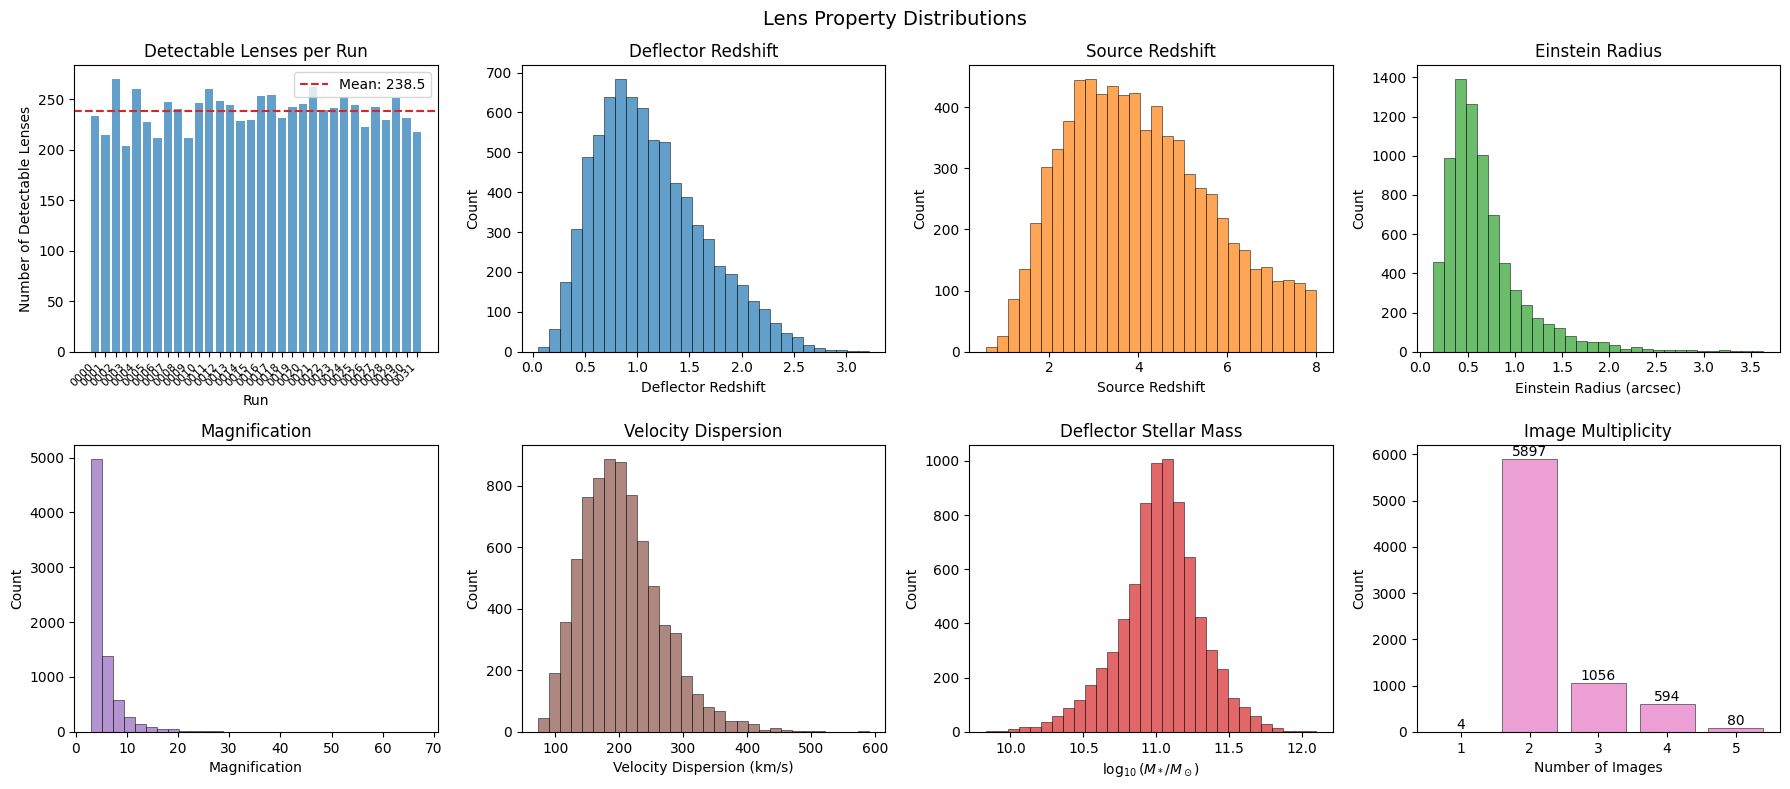

In [7]:
# Figure 1: distributions of lens properties
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

run_labels = [name.replace('detectable_gglenses_', '').replace('.pkl', '') for name, _ in file_counts]
counts = [c for _, c in file_counts]
axes[0, 0].bar(range(len(counts)), counts, color='C0', alpha=0.7)
axes[0, 0].axhline(np.mean(counts), color='C3', linestyle='--', label=f'Mean: {np.mean(counts):.1f}')
axes[0, 0].set_xlabel('Run')
axes[0, 0].set_ylabel('Number of Detectable Lenses')
axes[0, 0].set_title('Detectable Lenses per Run')
axes[0, 0].set_xticks(range(len(counts)))
axes[0, 0].set_xticklabels(run_labels, rotation=45, ha='right', fontsize=8)
axes[0, 0].legend()

axes[0, 1].hist(z_deflector, bins=30, alpha=0.7, color='C0', edgecolor='black', linewidth=0.5)
axes[0, 1].set_xlabel('Deflector Redshift')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Deflector Redshift')

axes[0, 2].hist(z_source, bins=30, alpha=0.7, color='C1', edgecolor='black', linewidth=0.5)
axes[0, 2].set_xlabel('Source Redshift')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Source Redshift')

axes[0, 3].hist(einstein_radii, bins=30, alpha=0.7, color='C2', edgecolor='black', linewidth=0.5)
axes[0, 3].set_xlabel('Einstein Radius (arcsec)')
axes[0, 3].set_ylabel('Count')
axes[0, 3].set_title('Einstein Radius')

axes[1, 0].hist(magnifications, bins=30, alpha=0.7, color='C4', edgecolor='black', linewidth=0.5)
axes[1, 0].set_xlabel('Magnification')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Magnification')

axes[1, 1].hist(velocity_dispersions, bins=30, alpha=0.7, color='C5', edgecolor='black', linewidth=0.5)
axes[1, 1].set_xlabel('Velocity Dispersion (km/s)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Velocity Dispersion')

axes[1, 2].hist(np.log10(stellar_masses), bins=30, alpha=0.7, color='C3', edgecolor='black', linewidth=0.5)
axes[1, 2].set_xlabel(r'$\log_{10}(M_*/M_\odot)$')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Deflector Stellar Mass')

unique, counts_mult = np.unique(image_numbers, return_counts=True)
axes[1, 3].bar(unique, counts_mult, color='C6', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1, 3].set_xlabel('Number of Images')
axes[1, 3].set_ylabel('Count')
axes[1, 3].set_title('Image Multiplicity')
axes[1, 3].set_xticks(unique)
for u, c in zip(unique, counts_mult):
    axes[1, 3].text(u, c + 0.5, str(c), ha='center', va='bottom', fontsize=10)

fig.suptitle('Lens Property Distributions', fontsize=14)
plt.tight_layout()
plt.show()

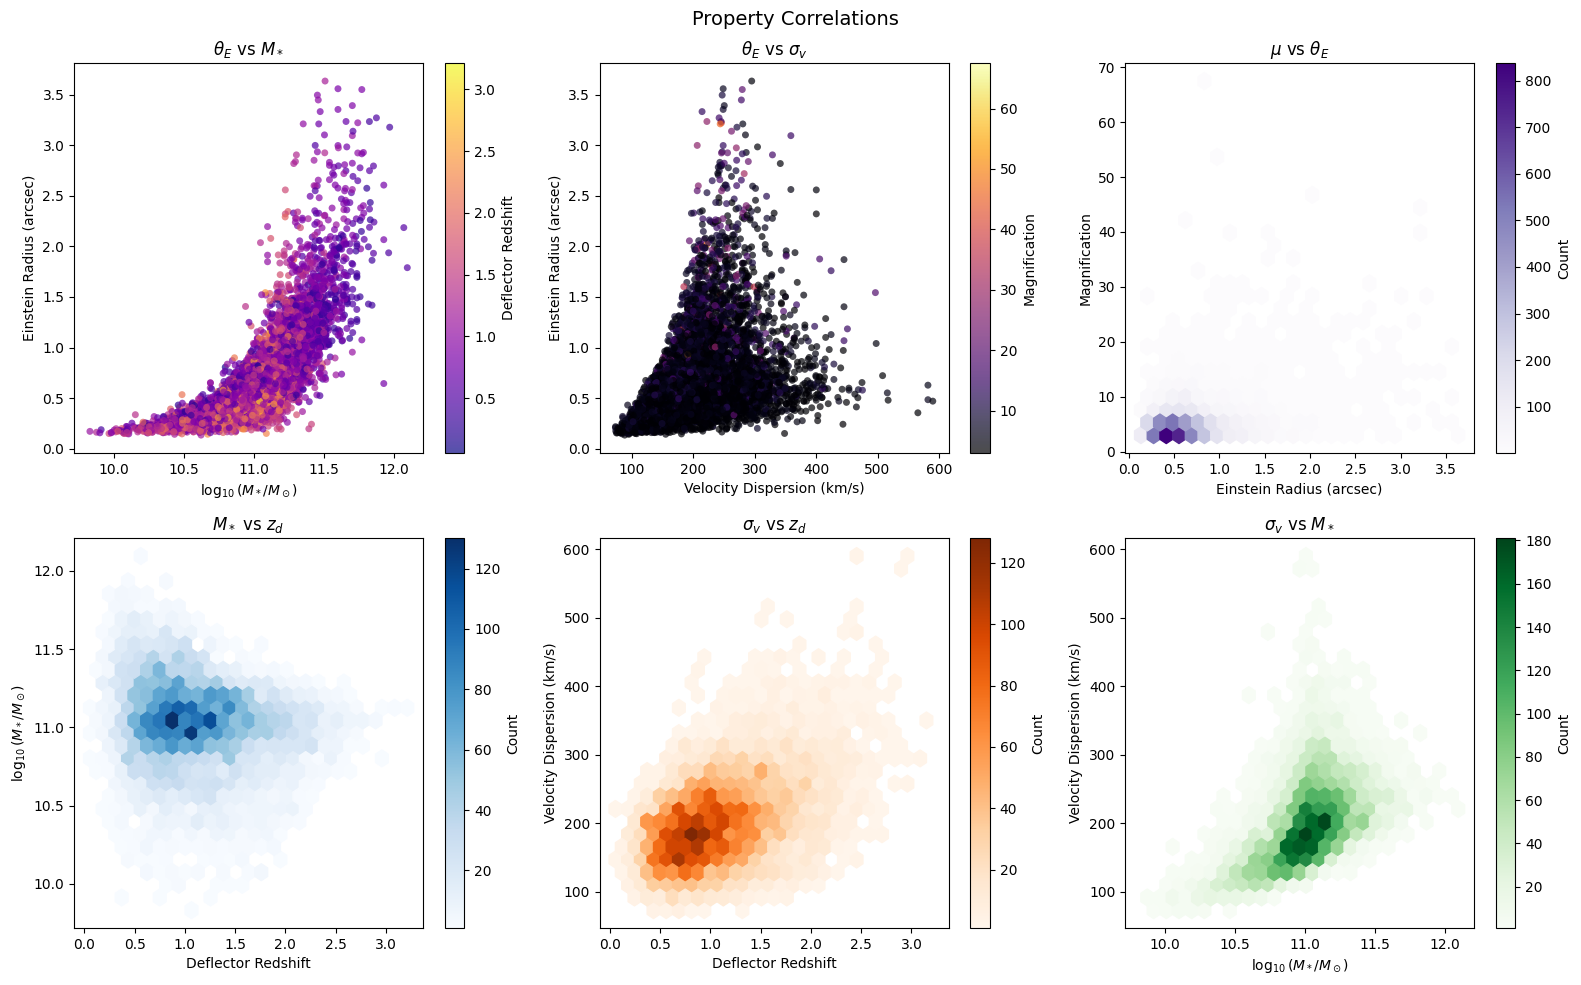

In [8]:
# Figure 2: property correlations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sc0 = axes[0, 0].scatter(np.log10(stellar_masses), einstein_radii, c=z_deflector, cmap='plasma', alpha=0.7, s=25, edgecolors='none')
plt.colorbar(sc0, ax=axes[0, 0], label='Deflector Redshift')
axes[0, 0].set_xlabel(r'$\log_{10}(M_*/M_\odot)$')
axes[0, 0].set_ylabel('Einstein Radius (arcsec)')
axes[0, 0].set_title(r'$\theta_E$ vs $M_*$')

sc1 = axes[0, 1].scatter(velocity_dispersions, einstein_radii, c=magnifications, cmap='inferno', alpha=0.7, s=25, edgecolors='none')
plt.colorbar(sc1, ax=axes[0, 1], label='Magnification')
axes[0, 1].set_xlabel('Velocity Dispersion (km/s)')
axes[0, 1].set_ylabel('Einstein Radius (arcsec)')
axes[0, 1].set_title(r'$\theta_E$ vs $\sigma_v$')

hb2 = axes[0, 2].hexbin(einstein_radii, magnifications, gridsize=25, cmap='Purples', mincnt=1)
plt.colorbar(hb2, ax=axes[0, 2], label='Count')
axes[0, 2].set_xlabel('Einstein Radius (arcsec)')
axes[0, 2].set_ylabel('Magnification')
axes[0, 2].set_title(r'$\mu$ vs $\theta_E$')

hb3 = axes[1, 0].hexbin(z_deflector, np.log10(stellar_masses), gridsize=25, cmap='Blues', mincnt=1)
plt.colorbar(hb3, ax=axes[1, 0], label='Count')
axes[1, 0].set_xlabel('Deflector Redshift')
axes[1, 0].set_ylabel(r'$\log_{10}(M_*/M_\odot)$')
axes[1, 0].set_title(r'$M_*$ vs $z_d$')

hb4 = axes[1, 1].hexbin(z_deflector, velocity_dispersions, gridsize=25, cmap='Oranges', mincnt=1)
plt.colorbar(hb4, ax=axes[1, 1], label='Count')
axes[1, 1].set_xlabel('Deflector Redshift')
axes[1, 1].set_ylabel('Velocity Dispersion (km/s)')
axes[1, 1].set_title(r'$\sigma_v$ vs $z_d$')

hb5 = axes[1, 2].hexbin(np.log10(stellar_masses), velocity_dispersions, gridsize=25, cmap='Greens', mincnt=1)
plt.colorbar(hb5, ax=axes[1, 2], label='Count')
axes[1, 2].set_xlabel(r'$\log_{10}(M_*/M_\odot)$')
axes[1, 2].set_ylabel('Velocity Dispersion (km/s)')
axes[1, 2].set_title(r'$\sigma_v$ vs $M_*$')

fig.suptitle('Property Correlations', fontsize=14)
plt.tight_layout()
plt.show()

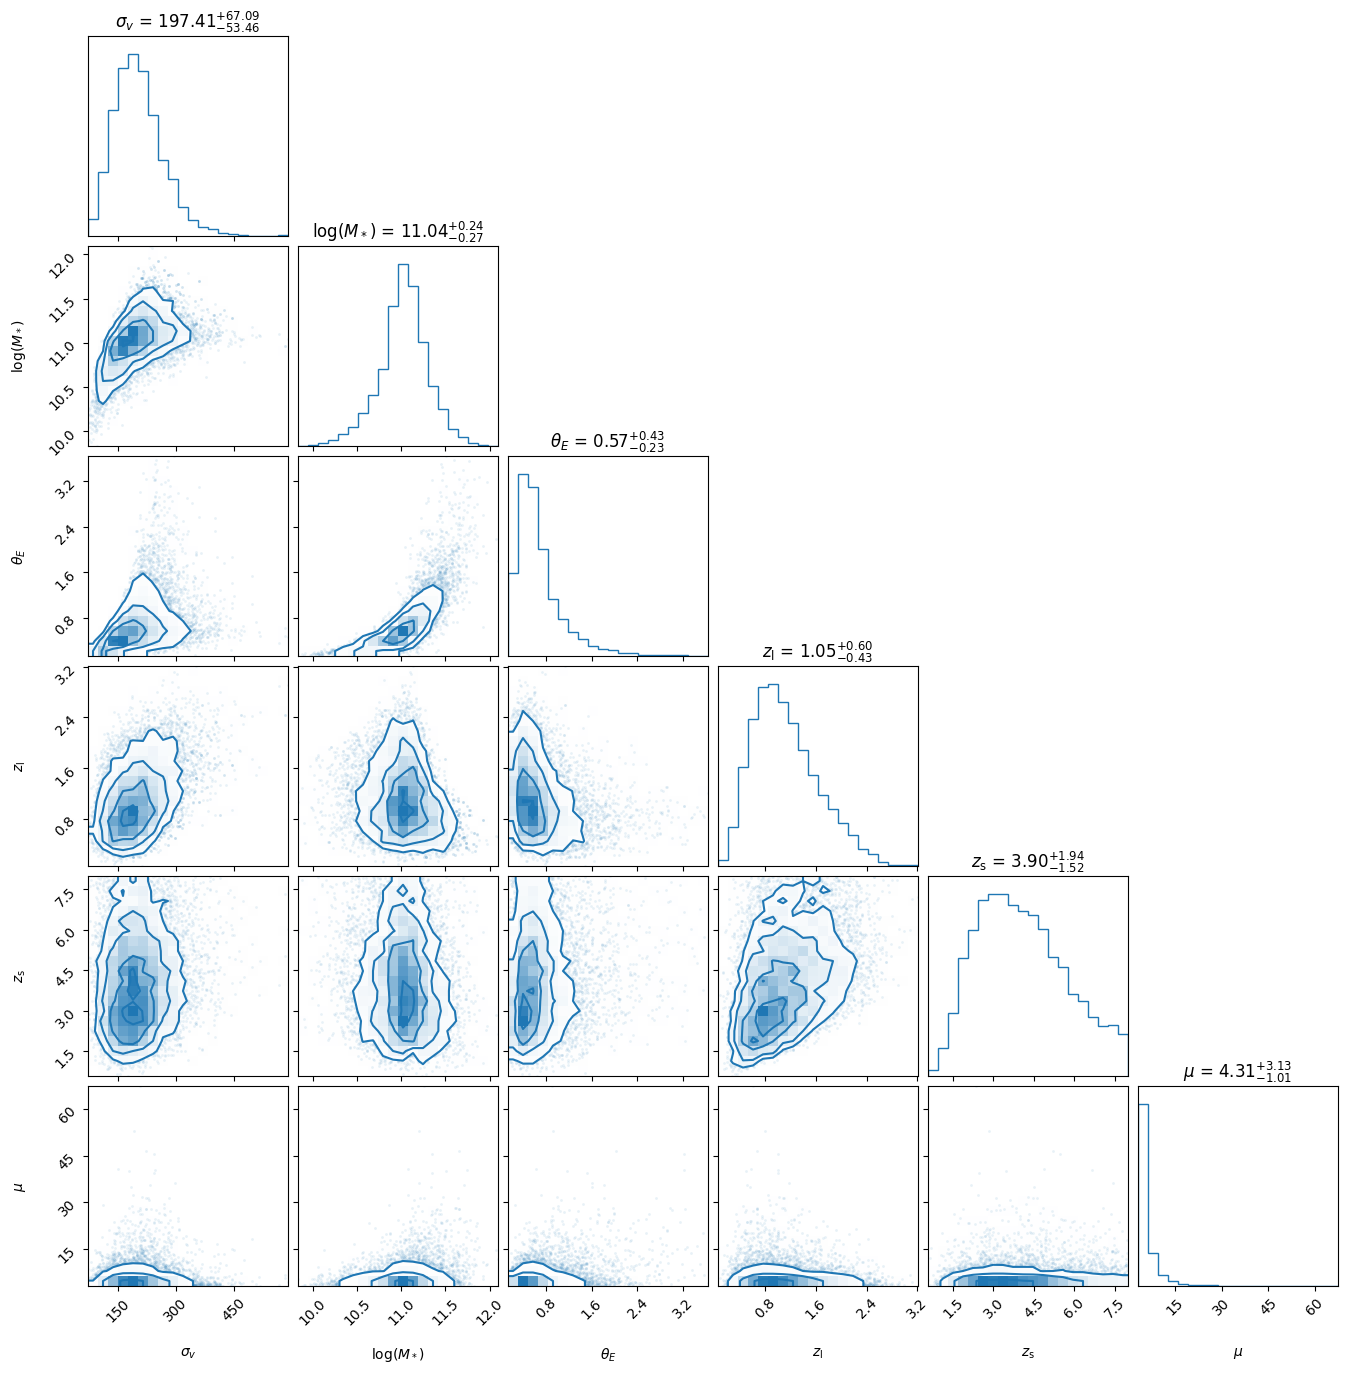

In [9]:
# Figure 3: corner plot of lens properties
labels = [
    r"$\sigma_v$",
    r"$\log(M_*)$",
    r"$\theta_E$",
    r"$z_{\rm l}$",
    r"$z_{\rm s}$",
    r"$\mu$",
]

sample = np.column_stack([
    velocity_dispersions,
    np.log10(stellar_masses),
    einstein_radii,
    z_deflector,
    z_source,
    magnifications,
])

corner(sample, labels=labels, show_titles=True, color='C0')
plt.show()